# 05. 대표 첫 구매 여정 분석

## 분석 개요

- 목적: 최초 동일 상품 조회 후 30일 내 대표 첫 구매가 같은 세션의 선형 퍼널 밖에서 어떤 경로로 나타나는지 확인하고, 장바구니 알림 실험의 기준선을 설계한다.
- 분석 단위: 구매 경로는 `user_id × product_id`, 장바구니 시간 지표와 실험 배정은 사용자(`user_id`)이다.
- 관측 기간: 2019-10-01-2020-02-29이다. 30일 또는 7일의 전체 추적 기간을 확보한 조합만 각 지표의 분모에 포함한다.
- 데이터 소스: `mart_user_product_session`을 기본으로 사용하고, 분석 테이블의 최초·최종 시각만으로 판정할 수 없는 조합만 원본 이벤트 로그 `events`에서 확인한다.
- 해석 원칙: 로그에서 확인된 선행 행동의 구성은 연관 신호이며, 구매 원인이나 장바구니 유지 상태를 확정하지 않는다.

In [1]:
import json
import os
import sys
from pathlib import Path
from urllib.parse import quote_plus

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import Markdown, display
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{quote_plus(os.getenv('DB_PASSWORD'))}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}?charset=utf8mb4"
)
pio.renderers.default = 'plotly_mimetype'
COLORS = {'view':'#3B82F6','cart':'#F59E0B','purchase':'#10B981','attention':'#EF4444','neutral':'#94A3B8'}

In [2]:
def find_project_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / 'cache_context.json').is_file() and (base / 'sql').is_dir():
            return base
    raise FileNotFoundError(f'프로젝트 루트 없음 (cwd={Path.cwd()})')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from experiment_design import calculate_experiment_design
from query_cache import QueryCache, load_queries

SQL_FILE = PROJECT_ROOT / 'sql' / '05_purchase_journey_analysis.sql'
Q = load_queries(SQL_FILE)
QUERY_CACHE = QueryCache(
    engine=engine,
    sql_file=SQL_FILE,
    upstream_sql_files=(PROJECT_ROOT / 'sql' / '02_preprocessing_mart.sql',),
)

def run(name, refresh=False, **kwargs):
    return QUERY_CACHE.run(name, refresh=refresh, **kwargs)

def explain_table_accesses(query_name, params=None):
    plan_frame = pd.read_sql(text('EXPLAIN FORMAT=JSON ' + Q[query_name]), engine, params=params)
    plan = json.loads(plan_frame.iloc[0, 0])
    rows = []
    def walk(node):
        if isinstance(node, dict):
            if 'table_name' in node:
                rows.append({key: node.get(key) for key in (
                    'table_name','access_type','key','rows_examined_per_scan'
                )})
            for value in node.values():
                walk(value)
        elif isinstance(node, list):
            for value in node:
                walk(value)
    walk(plan)
    return pd.DataFrame(rows)

---
## 1. 분석 목적·가설·핵심 정의

**가설 1.** 동일 세션의 조회→담기→구매 경로만으로는 30일 내 대표 첫 구매를 충분히 설명하기 어렵다.

**가설 2.** 동일 세션 3단계 밖의 대표 첫 구매 중에는 이전 세션의 장바구니 담기와 연결된 경로가 주요 유형으로 나타날 것이다.

**가설 3.** 최초 장바구니 담기 후 첫 24시간이 지난 미구매 집단은 다음 24시간 구매율이 크게 낮아질 것이다.

정식 추론 검정이 아니라 관찰 데이터의 구성을 확인하는 가설이다. 따라서 결과는 지지·입증이 아니라 관찰된 건수와 비율로 기술한다.

### 1.1 핵심 정의

| 항목 | 정의 |
|---|---|
| 분석 단위 | `user_id × product_id` |
| 기준 조회 시점 (수식에서는 `anchor`) | 관측 기간 내 사용자·상품별 최초 view |
| 30일 추적 가능 집단 | 기준 조회 시점 이후 30일 전체를 관측할 수 있는 사용자·상품 |
| 대표 첫 구매 | `anchor < purchase_at ≤ anchor + 30일`을 만족하는 가장 빠른 동일 상품 purchase |
| cart 탐색 범위 | `anchor < cart_at < 대표 첫 구매` |
| 동일 시각 처리 | 선후를 알 수 없으므로 시간 순서가 확인된 경로에서 제외 |
| 경로 우선순위 | 같은 세션 조회→담기→구매 → 같은 세션 담기(앞선 조회 미확인) → 이전 세션 담기 → 담기 미확인 |

기준 조회 시점 자체의 view는 같은 세션 시간 순서가 확인된 경로의 시작 view로 인정한다. 기준 조회 시점 이전 cart와 대표 구매와 같은 시각의 cart는 이번 여정에 포함하지 않는다.

> ### 섹션 결론
>
> - 30일 대표 첫 구매 한 건을 기준으로 네 경로를 서로 겹치지 않게 분류한다.
> - 동일 세션의 나중 구매가 아니라 가장 빠른 조건을 만족한 구매만 대표로 사용한다.

---
## 2. 30일 구매 cohort와 동일 세션 퍼널의 커버리지

대표 첫 구매 경로를 계산하기 전에 30일 전체 관측 가능 조합과 구매 전환 조합의 포함 관계를 확인한다. 네 경로 합계와 비교할 대표 첫 구매 cohort는 경로 분류 SQL과 별도로 계산한다.

분석 테이블의 압축 시각으로 확정할 수 없는 사례는 다음 두 조건으로 식별한다.

- 세션 내 최초 purchase와 마지막 purchase 사이에 기준 조회 시점이 있어 30일 내 실제 대표 구매를 알 수 없는 경우
- 다른 세션의 최초 cart가 기준 조회 시점 이전이고 마지막 cart가 대표 구매 이후여서 중간 cart 존재를 알 수 없는 경우

첫 조건은 마지막 purchase가 30일 밖에 있더라도 순서 판정 불가 후보에 포함한다. 원본 이벤트 로그에서 `anchor < purchase_at ≤ anchor + 30일`을 다시 적용하며, 조건을 만족한 purchase가 없는 후보는 구매 cohort와 경로 분류에서 제외한다.

원본 로그 조회는 이 순서 판정 불가 건의 키와 관련 세션으로 먼저 제한한다. 실행 전 `EXPLAIN`에서 `events`가 `idx_repeat_events`를 사용하며 `ALL` 접근이 아닌지 확인한다.

In [3]:
purchase_cohort = run('pj_30day_purchase_cohort')
mart_purchase_paths = run('pj_representative_purchase_mart')

boundary_keys = mart_purchase_paths.loc[
    mart_purchase_paths['row_type'].eq('raw 확인 경계'),
    ['user_id', 'product_id', 'anchor_view_at', 'boundary_type'],
].copy()
boundary_keys['user_id'] = boundary_keys['user_id'].astype('int64')
boundary_keys['product_id'] = boundary_keys['product_id'].astype('int64')
boundary_keys['anchor_view_at'] = pd.to_datetime(
    boundary_keys['anchor_view_at']
).dt.strftime('%Y-%m-%d %H:%M:%S')
boundary_json = json.dumps(
    boundary_keys.to_dict('records'), ensure_ascii=False, separators=(',', ':')
)
raw_params = {'boundary_json': boundary_json}

boundary_candidate_n = len(boundary_keys)
display(pd.DataFrame({
    '검산 항목': ['대표 구매·중간 cart raw 경계 후보'],
    '결과': [boundary_candidate_n],
}))
if boundary_candidate_n:
    raw_explain = explain_table_accesses('pj_boundary_raw_paths', raw_params)
    events_access = raw_explain.loc[raw_explain['table_name'].eq('event')].copy()
    assert not events_access.empty, 'EXPLAIN에서 raw events 접근을 찾지 못했다.'
    assert events_access['access_type'].ne('ALL').all(), 'events 전체 스캔 위험이 있어 실행을 중단한다.'
    assert events_access['key'].eq('idx_repeat_events').all(), 'idx_repeat_events를 사용하지 않아 실행을 중단한다.'
    raw_purchase_paths = run('pj_boundary_raw_paths', params=raw_params)
else:
    events_access = pd.DataFrame(columns=['table_name', 'access_type', 'key', 'rows_examined_per_scan'])
    raw_purchase_paths = pd.DataFrame(columns=[
        'user_id', 'product_id', 'anchor_view_at', 'boundary_type',
        'representative_purchase_at', 'eligible_purchase_flag',
        'path_order', 'representative_session_count', 'raw_event_count',
    ])
boundary_key_set = set(map(tuple, boundary_keys.astype(str).to_numpy()))
raw_key_frame = raw_purchase_paths[['user_id', 'product_id', 'anchor_view_at', 'boundary_type']].copy()
raw_key_frame['anchor_view_at'] = pd.to_datetime(raw_key_frame['anchor_view_at']).dt.strftime('%Y-%m-%d %H:%M:%S')
raw_key_set = set(map(tuple, raw_key_frame.astype(str).to_numpy()))
raw_missing_key_n = len(boundary_key_set - raw_key_set)
raw_unexpected_key_n = len(raw_key_set - boundary_key_set)
display(events_access.drop_duplicates().reset_index(drop=True))

[pj_30day_purchase_cohort] cache HIT 503148ef8f8e · 1행
[pj_representative_purchase_mart] cache HIT e446dce2ac5d · 342,457행


,검산 항목,결과
0,대표 구매·중간 cart raw 경계 후보,187


[pj_boundary_raw_paths] cache HIT 84e5f7054019 · 187행


,table_name,access_type,key,rows_examined_per_scan
0,event,ref,idx_repeat_events,4
1,event,ref,idx_repeat_events,1


In [4]:
PATH_LABELS = {
    1: '같은 세션 내 조회→담기→첫 구매',
    2: '같은 세션 내 담기→첫 구매 (앞선 조회 미확인)',
    3: '이전 세션에서 담은 뒤 첫 구매',
    4: '첫 구매 전 담기 미확인',
}
mart_confirmed = mart_purchase_paths.loc[mart_purchase_paths['row_type'].eq('마트 확정 경로')].copy()
raw_eligible = raw_purchase_paths.loc[raw_purchase_paths['eligible_purchase_flag'].eq(1)].copy()
raw_classified = raw_eligible.loc[raw_eligible['path_order'].notna()].copy()
raw_no_eligible_purchase_n = int(raw_purchase_paths['eligible_purchase_flag'].eq(0).sum())
raw_unresolved_eligible_n = int(raw_eligible['path_order'].isna().sum())

cohort_row = purchase_cohort.iloc[0]
eligible_30day_n = int(cohort_row['관측가능30일_사용자상품수'])
mart_purchase_cohort_n = int(cohort_row['마트확정_대표첫구매_사용자상품수'])
raw_purchase_boundary_eligible_n = int((
    raw_purchase_paths['boundary_type'].eq('대표 구매 시각 경계')
    & raw_purchase_paths['eligible_purchase_flag'].eq(1)
).sum())
representative_purchase_n = mart_purchase_cohort_n + raw_purchase_boundary_eligible_n

mart_counts = mart_confirmed.groupby('path_order').size()
raw_counts = raw_classified.groupby('path_order').size()
path_summary = pd.DataFrame({'경로순서': range(1, 5)})
path_summary['대표 첫 구매 경로'] = path_summary['경로순서'].map(PATH_LABELS)
path_summary['사용자·상품 수'] = (
    path_summary['경로순서'].map(mart_counts).fillna(0)
    + path_summary['경로순서'].map(raw_counts).fillna(0)
).astype('int64')
path_total_n = int(path_summary['사용자·상품 수'].sum())
path_summary['대표 첫 구매 내 비율(%)'] = path_summary['사용자·상품 수'] / representative_purchase_n * 100

classified_keys = pd.concat([
    mart_confirmed[['user_id', 'product_id']], raw_classified[['user_id', 'product_id']]
], ignore_index=True)
duplicate_n = int(len(classified_keys) - len(classified_keys.drop_duplicates()))
unclassified_n = int(representative_purchase_n - len(classified_keys.drop_duplicates()))
tie_n = int(
    mart_confirmed['representative_session_count'].fillna(0).gt(1).sum()
    + raw_classified['representative_session_count'].fillna(0).gt(1).sum()
)
percentage_sum = float(path_summary['대표 첫 구매 내 비율(%)'].sum())
validation = pd.DataFrame({
    '검산 항목': [
        '독립 계산 대표 첫 구매 cohort', '네 경로 합계', '비중 합계',
        '중복 분류', '미분류', '대표 구매 복수 세션 tie',
        '마트 확정 경로', 'raw 경계 후보', 'raw 적격 구매 확인',
        'raw 적격 구매 없음', 'raw 분류 완료', 'raw 적격 구매 미분류',
        'raw 누락 키', 'raw 예상 밖 키',
    ],
    '결과': [
        representative_purchase_n, path_total_n, percentage_sum,
        duplicate_n, unclassified_n, tie_n,
        len(mart_confirmed), len(boundary_keys), len(raw_eligible),
        raw_no_eligible_purchase_n, len(raw_classified), raw_unresolved_eligible_n,
        raw_missing_key_n, raw_unexpected_key_n,
    ],
})
assert path_total_n == representative_purchase_n
assert abs(percentage_sum - 100) < 1e-9
assert duplicate_n == 0 and unclassified_n == 0 and tie_n == 0
assert raw_unresolved_eligible_n == 0
assert raw_missing_key_n == 0 and raw_unexpected_key_n == 0
assert int(cohort_row['대표구매시각_raw경계후보_사용자상품수']) == int(
    boundary_keys['boundary_type'].eq('대표 구매 시각 경계').sum()
)
display(validation)

,검산 항목,결과
0,독립 계산 대표 첫 구매 cohort,342457.0
1,네 경로 합계,342457.0
2,비중 합계,100.0
3,중복 분류,0.0
4,미분류,0.0
5,대표 구매 복수 세션 tie,0.0
6,마트 확정 경로,342270.0
7,raw 경계 후보,187.0
8,raw 적격 구매 확인,187.0
9,raw 적격 구매 없음,0.0


In [5]:
cohort_summary = pd.DataFrame({
    '단계':['30일 관측 가능 사용자·상품','30일 내 대표 첫 구매 확인'],
    '사용자·상품 수':[eligible_30day_n,representative_purchase_n],
})
cohort_summary['30일 적격 cohort 대비 비율(%)'] = cohort_summary['사용자·상품 수'] / eligible_30day_n * 100
display(cohort_summary.round(3))

,단계,사용자·상품 수,30일 적격 cohort 대비 비율(%)
0,30일 관측 가능 사용자·상품,5323764,100.000
1,30일 내 대표 첫 구매 확인,342457,6.433


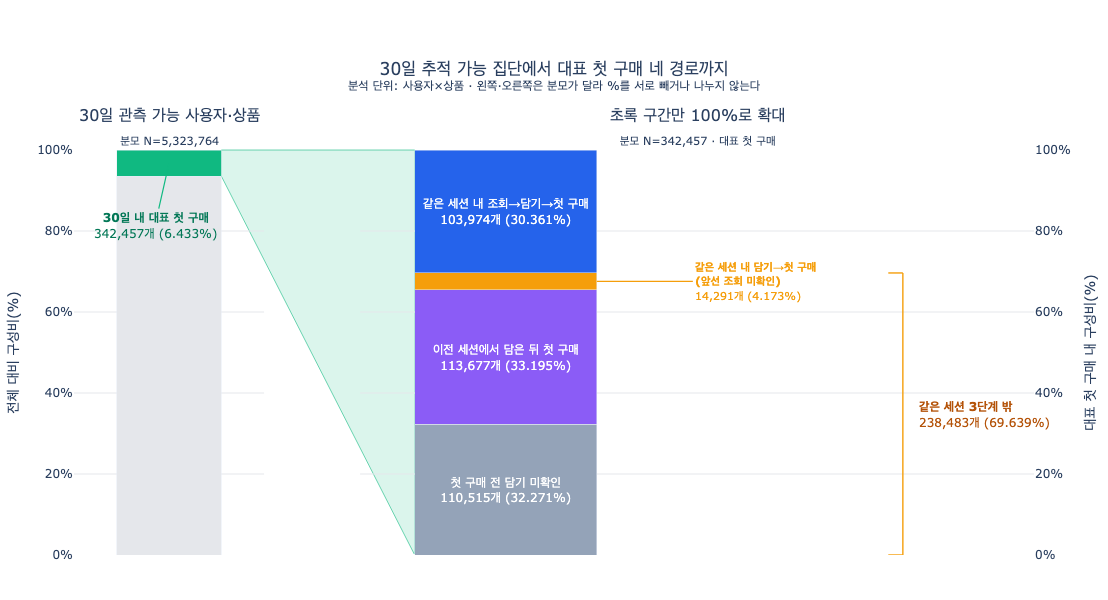

In [6]:
from plotly.subplots import make_subplots

non_purchase_n = eligible_30day_n - representative_purchase_n
same_visit_n = int(path_summary.loc[path_summary['경로순서'].eq(1), '사용자·상품 수'].iloc[0])
outside_same_visit_n = representative_purchase_n - same_visit_n
purchase_rate = representative_purchase_n / eligible_30day_n * 100
outside_rate = outside_same_visit_n / representative_purchase_n * 100
PATH_COLORS = {1:'#2563EB', 2:'#F59E0B', 3:'#8B5CF6', 4:'#94A3B8'}   # §3 경로 막대와 같은 색 체계
NARROW_PCT = 8.0                                                      # 이보다 좁으면 막대 안에 글자가 들어가지 않는다
LEFT_BAR_WIDTH, RIGHT_BAR_WIDTH = 0.55, 1.0
RIGHT_X_RANGE = (-0.8, 2.9)

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.22, 0.78], horizontal_spacing=0.10,
    subplot_titles=(f'30일 관측 가능 사용자·상품<br><sub>분모 N={eligible_30day_n:,}</sub>',
                    f'초록 구간만 100%로 확대<br><sub>분모 N={representative_purchase_n:,} · 대표 첫 구매</sub>'),
)
# 왼쪽: 전체 대비 구매 cohort 비중
fig.add_trace(go.Bar(
    x=['전체'], y=[100 - purchase_rate], marker_color='#E5E7EB', width=LEFT_BAR_WIDTH,
    hovertemplate=f'30일 내 구매 미확인<br>{non_purchase_n:,}개<br>%{{y:.3f}}%<extra></extra>', showlegend=False,
), row=1, col=1)
fig.add_trace(go.Bar(
    x=['전체'], y=[purchase_rate], marker_color=COLORS['purchase'], width=LEFT_BAR_WIDTH,
    hovertemplate=f'30일 내 대표 첫 구매<br>{representative_purchase_n:,}개<br>%{{y:.3f}}%<extra></extra>', showlegend=False,
), row=1, col=1)

# 오른쪽: 대표 첫 구매를 100%로 두고 네 경로까지 세부 분해 (경로 1이 위)
narrow_callouts = []
for _, row in path_summary.iloc[::-1].iterrows():
    order = int(row['경로순서'])
    count = int(row['사용자·상품 수'])
    pct = float(row['대표 첫 구매 내 비율(%)'])
    is_wide = pct >= NARROW_PCT
    fig.add_trace(go.Bar(
        x=['대표 첫 구매'], y=[pct], marker_color=PATH_COLORS[order], width=RIGHT_BAR_WIDTH,
        text=[f"{row['대표 첫 구매 경로']}<br>{count:,}개 ({pct:.3f}%)"] if is_wide else [''],
        textposition='inside', insidetextanchor='middle', textfont=dict(color='white', size=12),
        hovertemplate=f"{row['대표 첫 구매 경로']}<br>{count:,}개<br>%{{y:.3f}}%<extra></extra>", showlegend=False,
    ), row=1, col=2)
    if not is_wide:
        narrow_callouts.append((order, row['대표 첫 구매 경로'], count, pct))

fig.update_layout(
    barmode='stack', height=600, bargap=0.35, paper_bgcolor='white', plot_bgcolor='white',
    title=dict(text='30일 추적 가능 집단에서 대표 첫 구매 네 경로까지<br>'
                    '<sup>분석 단위: 사용자×상품 · 왼쪽·오른쪽은 분모가 달라 %를 서로 빼거나 나누지 않는다</sup>', x=0.5),
    margin=dict(l=70, r=70, t=150, b=45),
)
fig.update_yaxes(range=[0, 100], ticksuffix='%', gridcolor='#E5E7EB',
                 title_text='전체 대비 구성비(%)', row=1, col=1)
fig.update_yaxes(range=[0, 100], ticksuffix='%', gridcolor='#E5E7EB',
                 title_text='대표 첫 구매 내 구성비(%)', side='right', row=1, col=2)
fig.update_xaxes(showticklabels=False, range=[-0.5, 0.5], row=1, col=1)
fig.update_xaxes(showticklabels=False, range=list(RIGHT_X_RANGE), row=1, col=2)

# 확대 띠: 왼쪽 초록 구간의 모서리와 오른쪽 막대의 모서리를 실제 좌표로 잇는다
left_x0, left_x1 = fig.layout.xaxis.domain
right_x0, right_x1 = fig.layout.xaxis2.domain
domain_y0, domain_y1 = fig.layout.yaxis.domain
def _paper_y(value_pct):
    return domain_y0 + value_pct / 100 * (domain_y1 - domain_y0)
left_bar_right = left_x0 + (left_x1 - left_x0) * (LEFT_BAR_WIDTH / 2 + 0.5)
right_span = RIGHT_X_RANGE[1] - RIGHT_X_RANGE[0]
right_bar_left = right_x0 + (right_x1 - right_x0) * (
    (-RIGHT_BAR_WIDTH / 2 - RIGHT_X_RANGE[0]) / right_span
)
fig.add_shape(
    type='path', xref='paper', yref='paper', layer='below',
    path=(f'M {left_bar_right},{_paper_y(100)} L {right_bar_left},{domain_y1} '
          f'L {right_bar_left},{domain_y0} L {left_bar_right},{_paper_y(100 - purchase_rate)} Z'),
    fillcolor='rgba(16,185,129,0.15)', line=dict(color='rgba(16,185,129,0.6)', width=1),
)
fig.add_annotation(
    x=(left_x0 + left_x1) / 2, y=_paper_y(100 - purchase_rate / 2), xref='paper', yref='paper',
    text=f'<b>30일 내 대표 첫 구매</b><br>{representative_purchase_n:,}개 ({purchase_rate:.3f}%)',
    showarrow=True, arrowhead=0, arrowwidth=1.2, arrowcolor=COLORS['purchase'],
    ax=-14, ay=62, font=dict(size=12, color='#047857'), align='center',
)
# 좁은 경로는 막대 밖으로 빼서 지시선으로 잇는다
for order, label, count, pct in narrow_callouts:
    below = float(path_summary.loc[path_summary['경로순서'].gt(order), '대표 첫 구매 내 비율(%)'].sum())
    fig.add_annotation(
        x=RIGHT_BAR_WIDTH / 2, y=below + pct / 2, xref='x2', yref='y2',
        text=f'<b>{label.replace("(", "<br>(")}</b><br>{count:,}개 ({pct:.3f}%)',
        showarrow=True, arrowhead=0, arrowwidth=1.2, arrowcolor=PATH_COLORS[order],
        ax=96, ay=0, xanchor='left', font=dict(size=11, color=PATH_COLORS[order]), align='left',
    )
# 경로 2~4를 묶어 '같은 세션 3단계 밖' 규모를 표시한다
bracket_x, tick_x = 2.18, 2.10
fig.add_shape(type='line', xref='x2', yref='y2', x0=bracket_x, x1=bracket_x, y0=0, y1=outside_rate,
              line=dict(color=COLORS['cart'], width=1.4))
for y_end in (0, outside_rate):
    fig.add_shape(type='line', xref='x2', yref='y2', x0=tick_x, x1=bracket_x, y0=y_end, y1=y_end,
                  line=dict(color=COLORS['cart'], width=1.4))
fig.add_annotation(
    x=bracket_x + 0.08, y=outside_rate / 2, xref='x2', yref='y2', xanchor='left',
    text=f'<b>같은 세션 3단계 밖</b><br>{outside_same_visit_n:,}개 ({outside_rate:.3f}%)',
    showarrow=False, font=dict(size=12, color='#B45309'), align='left',
)
fig.show()

In [7]:
same_visit_n = int(path_summary.loc[
    path_summary['경로순서'].eq(1), '사용자·상품 수'
].iloc[0])
outside_same_visit_n = representative_purchase_n - same_visit_n
outside_same_visit_rate = outside_same_visit_n / representative_purchase_n * 100
same_visit_rate = same_visit_n / representative_purchase_n * 100
display(Markdown(f'''> ### 섹션 결론
>
> - 30일 전체를 관측할 수 있는 사용자·상품은 **{eligible_30day_n:,}개**이며, 경로와 독립적으로 계산한 대표 첫 구매 cohort는 **{representative_purchase_n:,}개**이다.
> - 같은 세션 내 조회→담기→첫 구매는 **{same_visit_n:,}개({same_visit_rate:.3f}%)** 이다.
> - 같은 세션 시간 순서가 확인된 3단계 밖의 대표 첫 구매는 **{outside_same_visit_n:,}개({outside_same_visit_rate:.3f}%)** 로, 동일 세션 경로만으로는 대표 첫 구매의 다수를 설명하기 어렵다.
> - 원본에서 확인할 후보 {len(boundary_keys):,}개 중 조건을 만족한 구매가 확인된 조합은 {len(raw_eligible):,}개, 조건을 만족한 구매가 없는 조합은 {raw_no_eligible_purchase_n:,}개다. 추적 가능한 조합은 모두 한 경로로 분류됐다.'''))

> ### 섹션 결론
>
> - 30일 전체를 관측할 수 있는 사용자·상품은 **5,323,764개**이며, 경로와 독립적으로 계산한 대표 첫 구매 cohort는 **342,457개**이다.
> - 같은 세션 내 조회→담기→첫 구매는 **103,974개(30.361%)** 이다.
> - 같은 세션 시간 순서가 확인된 3단계 밖의 대표 첫 구매는 **238,483개(69.639%)** 로, 동일 세션 경로만으로는 대표 첫 구매의 다수를 설명하기 어렵다.
> - 원본에서 확인할 후보 187개 중 조건을 만족한 구매가 확인된 조합은 187개, 조건을 만족한 구매가 없는 조합은 0개다. 추적 가능한 조합은 모두 한 경로로 분류됐다.

---
## 3. 대표 첫 구매 네 경로

대표 첫 구매를 다음 우선순위로 한 경로에만 배정한다.

1. 같은 세션 내 조회→담기→첫 구매
2. 같은 세션 내 담기→첫 구매 (앞선 조회 미확인)
3. 이전 세션에서 담은 뒤 첫 구매
4. 첫 구매 전 담기 미확인

경로 2는 구매한 세션에 담기는 있지만 그 세션 안에서 담기보다 앞선 조회를 확인하지 못한 경우이다. 경로 1과 같은 세션이며 조회 단계만 확인되지 않는다. 이전 세션에서 이미 봤거나 조회 로그가 남지 않았을 수 있으므로 조회를 건너뛴 구매로 단정하지 않는다. 경로 3은 구매한 세션에는 앞선 담기가 없고, 다른 세션에서 기준 조회 시점 이후·대표 구매 이전 담기가 확인된 경우이다.

In [8]:
path_table = path_summary.rename(columns={'사용자·상품 수':'사용자·상품 수(N)','대표 첫 구매 내 비율(%)':'비율(%)'})
display(path_table.round(3))

,경로순서,대표 첫 구매 경로,사용자·상품 수(N),비율(%)
0,1,같은 세션 내 조회→담기→첫 구매,103974,30.361
1,2,같은 세션 내 담기→첫 구매 (앞선 조회 미확인),14291,4.173
2,3,이전 세션에서 담은 뒤 첫 구매,113677,33.195
3,4,첫 구매 전 담기 미확인,110515,32.271


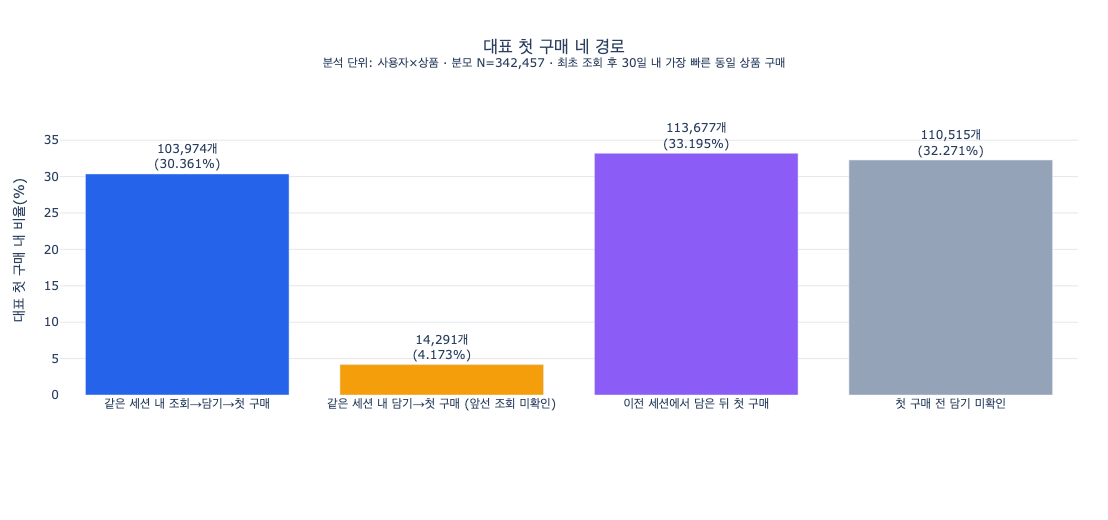

In [9]:
chart_data = path_summary.copy()
chart_data['표시 라벨'] = chart_data.apply(lambda row:f"{int(row['사용자·상품 수']):,}개<br>({row['대표 첫 구매 내 비율(%)']:.3f}%)",axis=1)
fig = go.Figure(go.Bar(
    x=chart_data['대표 첫 구매 경로'],y=chart_data['대표 첫 구매 내 비율(%)'],text=chart_data['표시 라벨'],textposition='outside',cliponaxis=False,
    marker_color=['#2563EB','#F59E0B','#8B5CF6','#94A3B8'],customdata=chart_data[['사용자·상품 수']],
    hovertemplate='%{x}<br>%{customdata[0]:,}개<br>%{y:.3f}%<extra></extra>',
))
fig.update_layout(
    title=dict(text=f'대표 첫 구매 네 경로<br><sup>분석 단위: 사용자×상품 · 분모 N={representative_purchase_n:,} · 최초 조회 후 30일 내 가장 빠른 동일 상품 구매</sup>',x=0.5),
    xaxis_title=None,yaxis_title='대표 첫 구매 내 비율(%)',
    # 막대 바깥 레이블 2줄이 잘리지 않도록 축 상단에 여유를 둔다.
    yaxis=dict(gridcolor='#E5E7EB',range=[0,chart_data['대표 첫 구매 내 비율(%)'].max()*1.20]),
    paper_bgcolor='white',plot_bgcolor='white',height=520,margin=dict(l=60,r=30,t=105,b=125),
)
fig.show()

In [10]:
previous_cart_row = path_summary.loc[path_summary['경로순서'].eq(3)].iloc[0]
no_cart_row = path_summary.loc[path_summary['경로순서'].eq(4)].iloc[0]
display(Markdown(f'''> ### 섹션 결론
>
> - 이전 세션에서 담은 뒤 첫 구매한 경로는 **{int(previous_cart_row['사용자·상품 수']):,}개({previous_cart_row['대표 첫 구매 내 비율(%)']:.3f}%)** 로 관찰됐다.
> - 첫 구매 전 cart를 확인하지 못한 경로도 **{int(no_cart_row['사용자·상품 수']):,}개({no_cart_row['대표 첫 구매 내 비율(%)']:.3f}%)** 이다. 이벤트 누락·직접 구매·관측 시작 이전 행동을 구분할 수 없으므로 실제 cart 생략으로 단정하지 않는다.
> - 네 경로의 합은 {representative_purchase_n:,}개이며 중복과 미분류, 대표 구매 복수 세션 tie는 모두 0개이다.'''))

> ### 섹션 결론
>
> - 이전 세션에서 담은 뒤 첫 구매한 경로는 **113,677개(33.195%)** 로 관찰됐다.
> - 첫 구매 전 cart를 확인하지 못한 경로도 **110,515개(32.271%)** 이다. 이벤트 누락·직접 구매·관측 시작 이전 행동을 구분할 수 없으므로 실제 cart 생략으로 단정하지 않는다.
> - 네 경로의 합은 342,457개이며 중복과 미분류, 대표 구매 복수 세션 tie는 모두 0개이다.

---
## 4. 장바구니 이후 구간별 다음 24시간 구매율

**가설 3.** 최초 장바구니 담기 후 첫 24시간이 지난 미구매 집단은 다음 24시간 구매율이 크게 낮아질 것이다.

사용자별 최초 관측 cart 한 건을 선택하고 같은 상품의 다음 구매를 찾는다. 최초 cart 이후 7일 전체를 관측할 수 있는 사용자를 공통 cohort로 두며, 각 구간의 분모는 구간 시작까지 동일 상품을 구매하지 않은 사용자이다.

구간별 구매율은 구간마다 분모가 달라 서로 더할 수 없으므로, 최초 담기 사용자 전체를 고정 분모로 둔 누적 구매율을 함께 제시한다.

cart가 세션 내 최초 purchase와 마지막 purchase 사이에 있는 순서 판정 불가 건은 별도로 추출한다. 해당 건이 있으면 관련 사용자·상품·세션의 cart 이후 31일 범위만 원본 로그 조회하고 실제 다음 purchase로 교체한다. 실행 전 `EXPLAIN`에서 `idx_repeat_events` 사용과 `ALL` 접근 부재를 확인한다.

In [11]:
cart_purchase_boundaries = run('pj_cart_purchase_boundaries')
cart_boundary_keys = cart_purchase_boundaries.copy()
cart_boundary_keys['user_id'] = cart_boundary_keys['user_id'].astype('int64')
cart_boundary_keys['product_id'] = cart_boundary_keys['product_id'].astype('int64')
cart_boundary_keys['cart_anchor_at'] = pd.to_datetime(cart_boundary_keys['cart_anchor_at']).dt.strftime('%Y-%m-%d %H:%M:%S')
cart_boundary_json = json.dumps(cart_boundary_keys.to_dict('records'), ensure_ascii=False, separators=(',', ':'))
cart_raw_params = {'cart_boundary_json': cart_boundary_json}

cart_boundary_candidate_n = len(cart_boundary_keys)
display(pd.DataFrame({
    '검산 항목': ['최초 cart 다중 purchase 경계 후보'],
    '결과': [cart_boundary_candidate_n],
}))
if cart_boundary_candidate_n:
    cart_raw_explain = explain_table_accesses('pj_cart_boundary_raw_next_purchase', cart_raw_params)
    cart_events_access = cart_raw_explain.loc[cart_raw_explain['table_name'].eq('event')].copy()
    assert not cart_events_access.empty, 'EXPLAIN에서 cart 경계 raw events 접근을 찾지 못했다.'
    assert cart_events_access['access_type'].ne('ALL').all(), 'events 전체 스캔 위험이 있어 실행을 중단한다.'
    assert cart_events_access['key'].eq('idx_repeat_events').all(), 'idx_repeat_events를 사용하지 않아 실행을 중단한다.'
    cart_raw_corrections = run('pj_cart_boundary_raw_next_purchase', params=cart_raw_params)
else:
    cart_events_access = pd.DataFrame(columns=['table_name', 'access_type', 'key', 'rows_examined_per_scan'])
    cart_raw_corrections = pd.DataFrame(columns=[
        'user_id', 'product_id', 'cart_anchor_at',
        'next_purchase_at', 'raw_purchase_event_count',
    ])

cart_boundary_key_set = set(map(tuple, cart_boundary_keys.astype(str).to_numpy()))
cart_raw_key_frame = cart_raw_corrections[['user_id', 'product_id', 'cart_anchor_at']].copy()
cart_raw_key_frame['cart_anchor_at'] = pd.to_datetime(cart_raw_key_frame['cart_anchor_at']).dt.strftime('%Y-%m-%d %H:%M:%S')
cart_raw_key_set = set(map(tuple, cart_raw_key_frame.astype(str).to_numpy()))
cart_raw_missing_key_n = len(cart_boundary_key_set - cart_raw_key_set)
cart_raw_unexpected_key_n = len(cart_raw_key_set - cart_boundary_key_set)
assert cart_raw_missing_key_n == 0 and cart_raw_unexpected_key_n == 0

cart_correction_records = []
for row in cart_raw_corrections.itertuples(index=False):
    cart_correction_records.append({
        'user_id': int(row.user_id),
        'product_id': int(row.product_id),
        'cart_anchor_at': pd.Timestamp(row.cart_anchor_at).strftime('%Y-%m-%d %H:%M:%S'),
        'next_purchase_at': (
            None if pd.isna(row.next_purchase_at)
            else pd.Timestamp(row.next_purchase_at).strftime('%Y-%m-%d %H:%M:%S')
        ),
    })
cart_boundary_corrections_json = json.dumps(
    cart_correction_records, ensure_ascii=False, separators=(',', ':')
)
cart_correction_params = {'cart_boundary_corrections_json': cart_boundary_corrections_json}

cart_purchase_rates = run('pj_cart_purchase_next_24h_rate', params=cart_correction_params)
cart_purchase_rates['구간별 다음 24시간 구매율(%)'] = (
    cart_purchase_rates['다음24시간_구매_사용자상품수']
    / cart_purchase_rates['구간시작_미구매_사용자상품수'] * 100
)
first_two_rates = cart_purchase_rates.iloc[:2].copy()
first_two_rates['표시 지표'] = ['0~24시간 구매율', '24~48시간 구매율']
first_cart_7day_observable_n = int(first_two_rates.iloc[0]['구간시작_미구매_사용자상품수'])
first_24h_nonpurchase_n = int(first_two_rates.iloc[1]['구간시작_미구매_사용자상품수'])

cart_boundary_validation = pd.DataFrame({
    '검산 항목': [
        '최초 cart 다중 purchase 경계 후보', 'raw 다음 purchase 확인',
        '31일 내 다음 purchase 미확인', 'raw 누락 키', 'raw 예상 밖 키',
    ],
    '결과': [
        cart_boundary_candidate_n, int(cart_raw_corrections['next_purchase_at'].notna().sum()),
        int(cart_raw_corrections['next_purchase_at'].isna().sum()),
        cart_raw_missing_key_n, cart_raw_unexpected_key_n,
    ],
})
display(cart_events_access.drop_duplicates().reset_index(drop=True))
display(cart_boundary_validation)
display(first_two_rates[[
    '표시 지표', '구간시작_미구매_사용자상품수',
    '다음24시간_구매_사용자상품수', '구간별 다음 24시간 구매율(%)',
]].round(3))

[pj_cart_purchase_boundaries] cache HIT 5ddc669864da · 129행


,검산 항목,결과
0,최초 cart 다중 purchase 경계 후보,129


[pj_cart_boundary_raw_next_purchase] cache HIT 463ab76ba565 · 129행
[pj_cart_purchase_next_24h_rate] cache HIT 1f09cc930bb4 · 7행


,table_name,access_type,key,rows_examined_per_scan
0,event,ref,idx_repeat_events,4


,검산 항목,결과
0,최초 cart 다중 purchase 경계 후보,129
1,raw 다음 purchase 확인,129
2,31일 내 다음 purchase 미확인,0
3,raw 누락 키,0
4,raw 예상 밖 키,0


,표시 지표,구간시작_미구매_사용자상품수,다음24시간_구매_사용자상품수,구간별 다음 24시간 구매율(%)
0,0~24시간 구매율,4082470,777301.0,19.040
1,24~48시간 구매율,3305169,53646.0,1.623


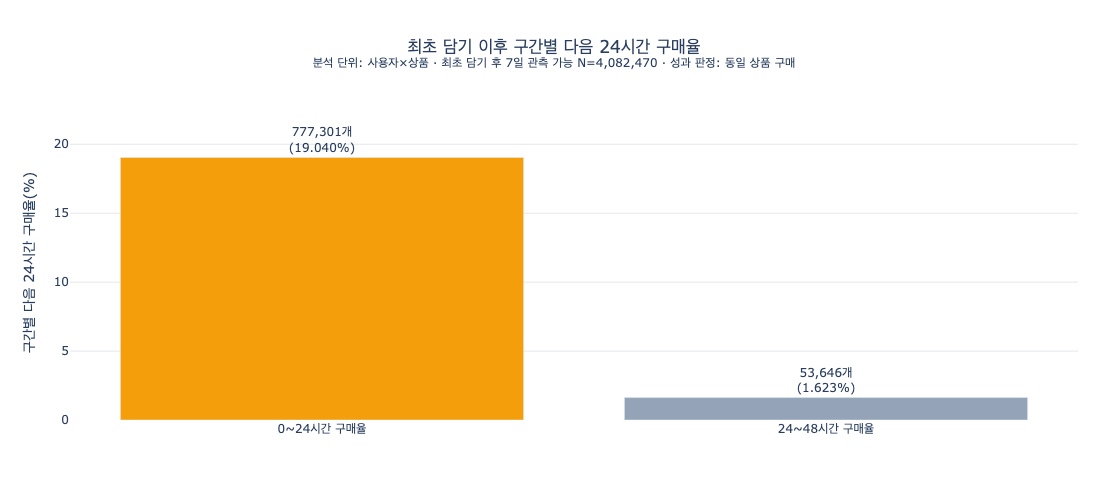

In [12]:
rate_chart = first_two_rates.copy()
rate_chart['표시 라벨'] = rate_chart.apply(lambda row:f"{int(row['다음24시간_구매_사용자상품수']):,}개<br>({row['구간별 다음 24시간 구매율(%)']:.3f}%)",axis=1)
fig = go.Figure(go.Bar(
    x=rate_chart['표시 지표'],y=rate_chart['구간별 다음 24시간 구매율(%)'],text=rate_chart['표시 라벨'],textposition='outside',cliponaxis=False,
    marker_color=[COLORS['cart'],COLORS['neutral']],customdata=rate_chart[['구간시작_미구매_사용자상품수']],
    hovertemplate='%{x}<br>구간 시작 미구매 N=%{customdata[0]:,}명<br>다음 24시간 구매율=%{y:.3f}%<extra></extra>',
))
fig.update_layout(
    title=dict(text=f'최초 담기 이후 구간별 다음 24시간 구매율<br><sup>분석 단위: 사용자×상품 · 최초 담기 후 7일 관측 가능 N={first_cart_7day_observable_n:,} · 성과 판정: 동일 상품 구매</sup>',x=0.5),
    xaxis_title=None,yaxis_title='구간별 다음 24시간 구매율(%)',
    # 막대 바깥 레이블 2줄이 잘리지 않도록 축 상단에 여유를 둔다.
    yaxis=dict(gridcolor='#E5E7EB',range=[0,rate_chart['구간별 다음 24시간 구매율(%)'].max()*1.20]),
    paper_bgcolor='white',plot_bgcolor='white',height=480,margin=dict(l=70,r=30,t=105,b=60),
)
fig.show()

In [13]:
# 구간별 구매율은 구간마다 분모(그 시점의 미구매자)가 달라 서로 더할 수 없다.
# 최초 담기 사용자 전체를 고정 분모로 둔 누적 구매율을 별도로 계산한다.
cumulative_rates = cart_purchase_rates.sort_values('구간순서').copy()
cumulative_rates['누적 구매 사용자상품수'] = (
    cumulative_rates['다음24시간_구매_사용자상품수'].fillna(0).cumsum().astype('int64')
)
cumulative_rates['누적 구매율(%)'] = (
    cumulative_rates['누적 구매 사용자상품수'] / first_cart_7day_observable_n * 100
)
cart_7day_cumulative_rate = float(cumulative_rates.iloc[-1]['누적 구매율(%)'])
first_24h_share_of_7day = (
    float(cumulative_rates.iloc[0]['누적 구매율(%)']) / cart_7day_cumulative_rate * 100
)
display(cumulative_rates[[
    '경과구간', '구간시작_미구매_사용자상품수', '다음24시간_구매_사용자상품수',
    '구간별 다음 24시간 구매율(%)', '누적 구매 사용자상품수', '누적 구매율(%)',
]].round(3))

,경과구간,구간시작_미구매_사용자상품수,다음24시간_구매_사용자상품수,구간별 다음 24시간 구매율(%),누적 구매 사용자상품수,누적 구매율(%)
0,0-24시간,4082470,777301.0,19.040,777301,19.040
1,24-48시간,3305169,53646.0,1.623,830947,20.354
2,48-72시간,3251523,30383.0,0.934,861330,21.098
3,72-96시간,3221140,20860.0,0.648,882190,21.609
4,96-120시간,3200280,16084.0,0.503,898274,22.003
5,120-144시간,3184196,12738.0,0.400,911012,22.315
6,144-168시간,3171458,11263.0,0.355,922275,22.591


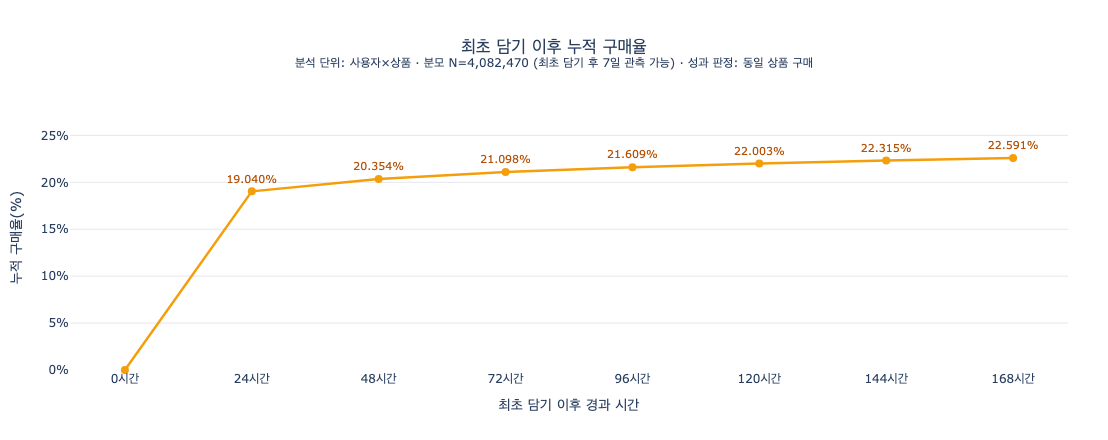

In [14]:
# 담기 시점(0시간·0%)을 시작점으로 붙여야 첫 24시간의 상승 폭이 드러난다.
curve_hours = ['0시간'] + [f"{int(h)}시간" for h in cumulative_rates['구간종료_시간']]
curve_rates = [0.0] + cumulative_rates['누적 구매율(%)'].tolist()
curve_users = [0] + cumulative_rates['누적 구매 사용자상품수'].tolist()
fig = go.Figure(go.Scatter(
    x=curve_hours, y=curve_rates, mode='lines+markers+text',
    line=dict(color=COLORS['cart'], width=2.5), marker=dict(size=8),
    text=[''] + [f"{v:.3f}%" for v in cumulative_rates['누적 구매율(%)']],
    textposition='top center', textfont=dict(size=11, color='#B45309'), cliponaxis=False,
    customdata=[[u] for u in curve_users],
    hovertemplate='담기 후 %{x}<br>누적 %{customdata[0]:,}명<br>누적 구매율 %{y:.3f}%<extra></extra>',
))
fig.update_layout(
    title=dict(text=f'최초 담기 이후 누적 구매율<br><sup>분석 단위: 사용자×상품 · 분모 N={first_cart_7day_observable_n:,} '
                    f'(최초 담기 후 7일 관측 가능) · 성과 판정: 동일 상품 구매</sup>', x=0.5),
    xaxis_title='최초 담기 이후 경과 시간', yaxis_title='누적 구매율(%)',
    # 마지막 점의 레이블이 잘리지 않도록 축 상단에 여유를 둔다.
    yaxis=dict(gridcolor='#E5E7EB', range=[0, cart_7day_cumulative_rate * 1.25], ticksuffix='%'),
    paper_bgcolor='white', plot_bgcolor='white', height=440,
    margin=dict(l=70, r=40, t=105, b=70),
)
fig.show()

In [15]:
rate_0_24 = float(first_two_rates.iloc[0]['구간별 다음 24시간 구매율(%)'])
rate_24_48 = float(first_two_rates.iloc[1]['구간별 다음 24시간 구매율(%)'])
display(Markdown(f'''> ### 섹션 결론
>
> - 최초 cart 순서 판정 불가 건 {len(cart_purchase_boundaries):,}개를 대상을 좁힌 원본 로그 조회로 보완한 뒤, 최초 cart 후 7일을 모두 관측할 수 있는 사용자·상품 조합은 **{first_cart_7day_observable_n:,}개**이다.
> - 0-24시간 구매율은 **{rate_0_24:.3f}%**, 첫 24시간을 미구매로 통과한 {first_24h_nonpurchase_n:,}개 조합의 24-48시간 구매율은 **{rate_24_48:.3f}%** 로 관찰됐다.
> - 최초 담기 사용자 전체를 분모로 둔 누적 구매율은 7일 시점 **{cart_7day_cumulative_rate:.3f}%** 이며, 그중 **{first_24h_share_of_7day:.1f}%** 가 첫 24시간에 발생했다.
> - 24시간 이후 낮아진 자연 구매율은 알림 시점의 후보 근거이며, 24시간 알림의 효과나 최적 시점을 뜻하지 않는다.'''))

> ### 섹션 결론
>
> - 최초 cart 순서 판정 불가 건 129개를 대상을 좁힌 원본 로그 조회로 보완한 뒤, 최초 cart 후 7일을 모두 관측할 수 있는 사용자·상품 조합은 **4,082,470개**이다.
> - 0-24시간 구매율은 **19.040%**, 첫 24시간을 미구매로 통과한 3,305,169개 조합의 24-48시간 구매율은 **1.623%** 로 관찰됐다.
> - 최초 담기 사용자 전체를 분모로 둔 누적 구매율은 7일 시점 **22.591%** 이며, 그중 **84.3%** 가 첫 24시간에 발생했다.
> - 24시간 이후 낮아진 자연 구매율은 알림 시점의 후보 근거이며, 24시간 알림의 효과나 최적 시점을 뜻하지 않는다.

---
## 5. 24시간 장바구니 알림 A/B 테스트 설계와 한계

관찰 결과를 제품 개입의 실제 효과로 표현하지 않고 후속 검증 설계로 연결한다. 사용자별 최초 cart 이후 24시간 동안 같은 상품을 구매하지 않은 사람 가운데, 그 기준 시점부터 7일을 추가로 관측할 수 있는 사용자를 실험 후보로 둔다.

- 무작위 배정 단위: `user_id`
- 대상 조건과 성과 판정: 동일 상품 기준
- 처리군: cart+24시간에 해당 상품 알림 1회 발송
- 대조군: 알림을 발송하지 않음
- 주지표: 기준 시점 후 7일 이내 동일 상품 구매율
- 보조지표: 기준 시점 후 30일 이내 동일 상품 구매율
- 가드레일: 수신 거부율·신고율, 사용자당 전체 구매 건수·전체 매출

첫 24시간 구간을 통과한 미구매 집단과, 그 기준 시점부터 이후 7일까지 추가 관측 가능한 실험 대상 집단을 구분한다. 두 집단의 차이는 추가 7일 관측 기간을 확보하지 못한 사용자이다.

### §4 누적 구매율과 기준선이 맞지 않는 이유

§4의 누적 곡선과 이 절의 기준선은 **기준 시점과 관측 창이 모두 달라** 뺄셈으로 검산되지 않는다.

| 구분 | 기준 시점 | 관측 창 | 분모 |
|---|---|---|---|
| §4 누적 구매율 | 최초 cart | cart 후 0~168시간(7일) | cart 후 7일 관측 가능 사용자 |
| §5 실험 기준선 | cart+24시간 | 기준 시점 후 7일 = cart 후 24~192시간(8일) | 첫 24시간 미구매이면서 cart 후 8일 관측 가능 사용자 |

분모는 `cart 후 7일 관측 가능 ⊃ 첫 24시간 미구매 ⊃ 실험 대상` 순서로 포함 관계지만, 실험은 관측 기간을 하루 더 요구하므로 우측 절단으로 빠지는 사용자가 더 많다. 분자도 실험 쪽이 168~192시간 구간을 추가로 포함한다. 따라서 `7일 누적 구매율 − 24시간 누적 구매율`과 실험 기준선은 서로 다른 값이며, 한쪽을 다른 쪽의 검산에 사용하지 않는다.

In [16]:
experiment_daily = run('pj_experiment_baseline', params=cart_correction_params)
experiment_daily['실험적격일'] = pd.to_datetime(experiment_daily['실험적격일'])
# 분석 단위는 30일 여정과 같은 (사용자, 상품) 쌍이다. 같은 캐시의 실험적격_사용자수는
# 일자별 distinct 사용자 수이며 표본 산정이 아니라 사용자 환산에만 쓴다.
experiment_eligible_n = int(experiment_daily['실험적격_사용자상품수'].sum())
purchase_7day_n = int(experiment_daily['기준점후_7일_동일상품구매_사용자상품수'].sum())
baseline_7day_rate = purchase_7day_n / experiment_eligible_n
daily_eligible_pairs = experiment_daily.set_index('실험적격일')['실험적격_사용자상품수']
experiment_design = calculate_experiment_design(
    baseline_rate=baseline_7day_rate,
    daily_eligible_users=daily_eligible_pairs,
    relative_mdes=(0.05,),
    alpha=0.05,
    power=0.80,
    tracking_days=7,
)
design_row = experiment_design.sample_size.iloc[0]

# 지표와 표본은 (사용자, 상품) 쌍이지만 배정·발송은 사용자 단위다.
# 같은 사용자가 다른 날 다시 적격이 될 수 있어 일자 기준 비율로 환산한다.
# 이 비율은 사용자당 쌍 수를 낮게 잡아, 필요 사용자 수를 크게(보수적으로) 만든다.
eligible_user_days_n = int(experiment_daily['실험적격_사용자수'].sum())

# 한 사용자의 여러 조합은 서로 독립이 아니다. 급내상관(ICC)을 실제로 재서
# 설계효과 1 + (n0 - 1) * ICC 만큼 필요 표본을 늘린다. 유의성은 보지 않고
# 값 자체를 반영한다(표본이 커서 아주 작은 ICC도 '유의'하게 나오기 때문).
cluster_dist = run('pj_experiment_user_cluster', params=cart_correction_params)
cluster_users = cluster_dist['사용자수'].astype('int64')
cluster_size = cluster_dist['보유_사용자상품수'].astype('int64')
# 한 사용자의 모든 행에서 다음 purchase가 없으면 SQL SUM()이 0이 아니라 NULL을 준다.
# 구매가 한 건도 없었다는 뜻이므로 0으로 채운다.
cluster_buys = cluster_dist['구매_사용자상품수'].fillna(0).astype('int64')
assert (cluster_buys <= cluster_size).all(), '구매 조합 수가 보유 조합 수를 넘는다.'

cluster_user_n = int(cluster_users.sum())
cluster_pair_n = int((cluster_users * cluster_size).sum())
assert cluster_pair_n == experiment_eligible_n, '적격 조합 수가 기준선 집계와 다르다.'

grand_rate = float((cluster_users * cluster_buys).sum() / cluster_pair_n)
user_rate = cluster_buys / cluster_size
mean_square_between = float(
    (cluster_users * cluster_size * (user_rate - grand_rate) ** 2).sum()
) / (cluster_user_n - 1)
mean_square_within = float(
    (cluster_users * cluster_size * user_rate * (1 - user_rate)).sum()
) / (cluster_pair_n - cluster_user_n)
adjusted_cluster_size = (
    cluster_pair_n - float((cluster_users * cluster_size ** 2).sum()) / cluster_pair_n
) / (cluster_user_n - 1)
intraclass_corr = max(0.0, (mean_square_between - mean_square_within) / (
    mean_square_between + (adjusted_cluster_size - 1) * mean_square_within
))
design_effect = 1 + (adjusted_cluster_size - 1) * intraclass_corr

required_pairs_n = -(-int(design_row['전체_필요표본수']) * int(round(design_effect * 1000)) // 1000)
required_users_n = -(-required_pairs_n * eligible_user_days_n // experiment_eligible_n)
# 모집 일수는 보정된 표본을 하루 유입으로 한 번에 나눠 구한다. 보정 전 모집일수(이미
# 올림된 값)에 설계효과를 곱하면 올림 오차까지 불어나 실제보다 길게 나온다.
recruit_days_n = -(-required_pairs_n // int(experiment_design.average_daily_eligible_users))
total_days_n = recruit_days_n + int(experiment_design.tracking_days)
conservative_days_n = -(
    -required_pairs_n // int(experiment_design.conservative_daily_eligible_users)
) + int(experiment_design.tracking_days)
# 필요 표본을 사용자 수로 환산한 값은 일자 기준이라 상한이다.
# 같은 사용자가 다른 날 다시 적격이 되면 중복 계산되므로, 고유 사용자 기준 하한도 함께 본다.
required_users_min_n = -(-required_pairs_n * cluster_user_n // experiment_eligible_n)
pairs_per_user_day = experiment_eligible_n / eligible_user_days_n
assert first_24h_nonpurchase_n >= experiment_eligible_n
assert purchase_7day_n <= experiment_eligible_n
experiment_metrics = pd.DataFrame({
    '검산 지표': [
        '최초 cart 후 7일 관측 가능 사용자·상품', '첫 24시간 미구매 사용자·상품',
        'cart+24시간부터 추가 7일 관측 가능한 실험 적격 사용자·상품',
        '실험 적격 집단의 7일 내 동일 상품 구매 사용자·상품',
        '7일 기준 구매율(%)', '상대 MDE(%)', '목표 구매율(%)',
        '보정 전 필요 표본(모든 쌍이 독립이라 가정)',
        '실험 적격 고유 사용자',
        '고유 사용자당 조합(설계효과용)', '일자별 조합/사용자(환산용)',
        '사용자 내 급내상관(ICC)', '설계효과(배)',
        '전체 필요 표본(사용자·상품 쌍)', '배정 기준 필요 사용자(일자 기준 상한)',
        '배정 기준 필요 사용자(고유 기준 하한)',
        '일 유입 평균(조합)', '모집 일수', '추적 일수',
        '평균 유입 기준 모집·추적 기간(일)',
        '유입이 적은 시기 기준 모집·추적 기간(일)',
    ],
    '결과': [
        first_cart_7day_observable_n, first_24h_nonpurchase_n,
        experiment_eligible_n, purchase_7day_n, baseline_7day_rate * 100,
        5.0, float(design_row['처리군_목표구매율_pct']),
        int(design_row['전체_필요표본수']),
        cluster_user_n,
        adjusted_cluster_size, pairs_per_user_day,
        intraclass_corr, design_effect,
        required_pairs_n, required_users_n, required_users_min_n,
        int(experiment_design.average_daily_eligible_users), recruit_days_n,
        int(experiment_design.tracking_days),
        total_days_n, conservative_days_n,
    ],
})

# 이전 실행값은 계산에 사용하지 않고, 경계 보완 후 결과의 회귀 검산에만 사용한다.
regression_check = pd.DataFrame({
    '검산 지표': [
        '0~24시간 구매율(%)', '24~48시간 구매율(%)',
        '실험 기준 구매율(%)', '전체 필요 표본',
        '평균 유입 기준 기간(일)', '유입이 적은 시기 기준 기간(일)',
    ],
    # 분석 단위를 사용자에서 (사용자, 상품)으로 바꾸기 전의 값이다. 같을 수 없고,
    # 얼마나 달라졌는지를 남겨 단위 변경의 영향을 드러내는 용도로만 둔다.
    '단위 변경 전 참고값(사용자 기준)': [15.413, 0.877, 2.536, 126548, 64, 84],
    '현재 계산값(사용자·상품 기준)': [
        float(first_two_rates.iloc[0]['구간별 다음 24시간 구매율(%)']),
        float(first_two_rates.iloc[1]['구간별 다음 24시간 구매율(%)']),
        baseline_7day_rate * 100, required_pairs_n,
        total_days_n, conservative_days_n,
    ],
})
regression_check['이전 값과 동일'] = [
    round(current, 3) == reference if index < 3 else int(current) == int(reference)
    for index, (reference, current) in enumerate(zip(
        regression_check['단위 변경 전 참고값(사용자 기준)'],
        regression_check['현재 계산값(사용자·상품 기준)'],
    ))
]
display(experiment_metrics.round(3))
display(regression_check.round(3))

[pj_experiment_baseline] cache HIT da088b64f42d · 144행
[pj_experiment_user_cluster] cache HIT 49e04b3161d2 · 4,485행


,검산 지표,결과
0,최초 cart 후 7일 관측 가능 사용자·상품,4082470.000
1,첫 24시간 미구매 사용자·상품,3305169.000
2,cart+24시간부터 추가 7일 관측 가능한 실험 적격 사용자·상품,3287385.000
3,실험 적격 집단의 7일 내 동일 상품 구매 사용자·상품,154517.000
4,7일 기준 구매율(%),4.700
5,상대 MDE(%),5.000
6,목표 구매율(%),4.935
7,보정 전 필요 표본(모든 쌍이 독립이라 가정),260662.000
8,실험 적격 고유 사용자,351393.000
9,고유 사용자당 조합(설계효과용),9.355


,검산 지표,단위 변경 전 참고값(사용자 기준),현재 계산값(사용자·상품 기준),이전 값과 동일
0,0~24시간 구매율(%),15.413,19.040,False
1,24~48시간 구매율(%),0.877,1.623,False
2,실험 기준 구매율(%),2.536,4.700,False
3,전체 필요 표본,126548.000,763479.000,False
4,평균 유입 기준 기간(일),64.000,41.000,False
5,유입이 적은 시기 기준 기간(일),84.000,45.000,False


In [17]:
experiment_summary = pd.DataFrame({
    '설계 항목':['무작위 배정','대상','처리군','대조군','주지표','보조지표','통계 조건','필요 표본','예상 기간','가드레일'],
    '정의':['user_id 단위 1:1 배정','최초 cart 후 24시간 동안 동일 상품 미구매, 이후 7일 관측 가능 (사용자, 상품) 조합','cart+24시간에 사용자당 1회 발송 — 적격 조합이 여럿이면 묶어서 한 번만 보낸다','알림 미발송','배정 후 7일 이내 동일 상품 구매율','배정 후 30일 이내 동일 상품 구매율','유의수준 5% · 검정력 80% · 양측 검정 · 상대 MDE 5%',f"전체 {required_pairs_n:,}쌍 · 배정 기준 {required_users_min_n:,}~{required_users_n:,}명",f"평균 유입 기준 약 {total_days_n}일 · 유입이 적은 시기 기준 약 {conservative_days_n}일 (설계효과 {design_effect:.2f}배 반영)",'수신 거부율·신고율 · 사용자당 전체 구매 건수·전체 매출'],
})
display(experiment_summary)

,설계 항목,정의
0,무작위 배정,user_id 단위 1:1 배정
1,대상,"최초 cart 후 24시간 동안 동일 상품 미구매, 이후 7일 관측 가능 (사용자,..."
2,처리군,cart+24시간에 사용자당 1회 발송 — 적격 조합이 여럿이면 묶어서 한 번만 보낸다
3,대조군,알림 미발송
4,주지표,배정 후 7일 이내 동일 상품 구매율
5,보조지표,배정 후 30일 이내 동일 상품 구매율
6,통계 조건,유의수준 5% · 검정력 80% · 양측 검정 · 상대 MDE 5%
7,필요 표본,"전체 763,479쌍 · 배정 기준 81,610~139,338명"
8,예상 기간,평균 유입 기준 약 41일 · 유입이 적은 시기 기준 약 45일 (설계효과 2.93...
9,가드레일,수신 거부율·신고율 · 사용자당 전체 구매 건수·전체 매출


In [18]:
display(Markdown(f'''> ### 섹션 결론
>
> - 첫 24시간 구간을 통과한 미구매 집단은 **{first_24h_nonpurchase_n:,}개**이고, 이 시점부터 7일을 더 관측할 수 있는 실험 대상 집단은 **{experiment_eligible_n:,}개**다. 차이는 추적 기간이 모자란 조합이다.
> - 실험 대상 조합 중 **{purchase_7day_n:,}개**가 기준 시점 후 7일 내 같은 상품을 구매해 자연 구매 기준선은 **{baseline_7day_rate * 100:.3f}%** 이다.
> - 이 기준선은 cart+24시간을 기준 시점으로 둔 값이라 §4의 누적 구매율(최초 cart 기준 168시간)과 기준 시점·관측 창·분모가 모두 달라 서로 빼거나 비교하지 않는다.
> - 한 사용자의 여러 조합은 서로 독립이 아니므로 급내상관을 직접 계산했다. ICC는 **{intraclass_corr:.4f}**, 사용자당 보정 조합 수는 **{adjusted_cluster_size:.2f}개**여서 설계효과는 **{design_effect:.2f}배**다. 필요 표본은 이 배수를 반영한 값이다.
> - 상대 MDE 5%의 목표 구매율은 **{float(design_row['처리군_목표구매율_pct']):.3f}%** 이며, 양측 검정·유의수준 5%·검정력 80% 조건에서 전체 **{required_pairs_n:,}개**의 (사용자, 상품) 쌍이 필요하다. 배정은 사용자 단위이므로 **{required_users_min_n:,}~{required_users_n:,}명**으로 환산된다. 아래값은 고유 사용자당 조합 {adjusted_cluster_size:.2f}개, 윗값은 일자별 조합/사용자 {pairs_per_user_day:.2f}개로 나눈 값이다.
> - 모집과 7일 추적을 합친 예상 기간은 평균 유입 기준 약 **{total_days_n}일**, 유입이 적은 시기 기준 약 **{conservative_days_n}일**이다.
> - 같은 사용자가 여러 상품 후보를 가질 수 있으므로 운영 단계에서는 중복 노출을 막거나 대표 후보 한 건을 선택하고, 분석에서는 표준오차를 사용자 단위로 군집 보정한다.
> - 모집 기간이 길어 계절성이 섞이지만 두 집단이 같은 기간을 겪으므로 비교 자체는 흔들리지 않는다. 다만 기간 중 장바구니 화면·알림 문구·중복 실험 노출은 고정해야 하며, 이는 배정으로 통제되지 않는다.
> - 현재 데이터에는 발송·노출·수신 동의 로그가 없다. 이 결과는 실제 효과가 아니라 후속 A/B 테스트 설계이다.
>
> ### 전체 한계
>
> - 관측 시작 이전 행동은 볼 수 없어 대표 첫 구매는 고객 생애 첫 구매가 아니다.
> - cart 미확인 경로에는 직접 구매뿐 아니라 이벤트 누락과 관측 시작 이전 행동이 섞일 수 있다.
> - 동일 초 이벤트의 선후는 정하지 않았고 시간 순서가 확인된 경로에서 제외했다.
> - 실제 발송 전에는 장바구니 유지, 상품 판매 상태, 수신 동의를 별도 로그로 확인해야 한다.'''))

> ### 섹션 결론
>
> - 첫 24시간 구간을 통과한 미구매 집단은 **3,305,169개**이고, 이 시점부터 7일을 더 관측할 수 있는 실험 대상 집단은 **3,287,385개**다. 차이는 추적 기간이 모자란 조합이다.
> - 실험 대상 조합 중 **154,517개**가 기준 시점 후 7일 내 같은 상품을 구매해 자연 구매 기준선은 **4.700%** 이다.
> - 이 기준선은 cart+24시간을 기준 시점으로 둔 값이라 §4의 누적 구매율(최초 cart 기준 168시간)과 기준 시점·관측 창·분모가 모두 달라 서로 빼거나 비교하지 않는다.
> - 한 사용자의 여러 조합은 서로 독립이 아니므로 급내상관을 직접 계산했다. ICC는 **0.2308**, 사용자당 보정 조합 수는 **9.36개**여서 설계효과는 **2.93배**다. 필요 표본은 이 배수를 반영한 값이다.
> - 상대 MDE 5%의 목표 구매율은 **4.935%** 이며, 양측 검정·유의수준 5%·검정력 80% 조건에서 전체 **763,479개**의 (사용자, 상품) 쌍이 필요하다. 배정은 사용자 단위이므로 **81,610~139,338명**으로 환산된다. 아래값은 고유 사용자당 조합 9.36개, 윗값은 일자별 조합/사용자 5.48개로 나눈 값이다.
> - 모집과 7일 추적을 합친 예상 기간은 평균 유입 기준 약 **41일**, 유입이 적은 시기 기준 약 **45일**이다.
> - 같은 사용자가 여러 상품 후보를 가질 수 있으므로 운영 단계에서는 중복 노출을 막거나 대표 후보 한 건을 선택하고, 분석에서는 표준오차를 사용자 단위로 군집 보정한다.
> - 모집 기간이 길어 계절성이 섞이지만 두 집단이 같은 기간을 겪으므로 비교 자체는 흔들리지 않는다. 다만 기간 중 장바구니 화면·알림 문구·중복 실험 노출은 고정해야 하며, 이는 배정으로 통제되지 않는다.
> - 현재 데이터에는 발송·노출·수신 동의 로그가 없다. 이 결과는 실제 효과가 아니라 후속 A/B 테스트 설계이다.
>
> ### 전체 한계
>
> - 관측 시작 이전 행동은 볼 수 없어 대표 첫 구매는 고객 생애 첫 구매가 아니다.
> - cart 미확인 경로에는 직접 구매뿐 아니라 이벤트 누락과 관측 시작 이전 행동이 섞일 수 있다.
> - 동일 초 이벤트의 선후는 정하지 않았고 시간 순서가 확인된 경로에서 제외했다.
> - 실제 발송 전에는 장바구니 유지, 상품 판매 상태, 수신 동의를 별도 로그로 확인해야 한다.